In [24]:
!pip install -q astroquery gala

from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
from gala.coordinates import GD1Koposov10

from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from scipy.spatial import cKDTree


from tqdm import tqdm
np.random.seed(42)



In [17]:
RA_MIN  = 120
RA_MAX  = 180

dec_lo = 0
dec_hi = 70


RA_STEP  = 10




# OUTPUT TABLE


all_tables = []






# QUERY LOOP


ra_edges = np.arange(RA_MIN, RA_MAX, RA_STEP)


for ra_lo in tqdm(ra_edges):

    ra_hi = ra_lo + RA_STEP



    print(
            f"\nQuerying RA=[{ra_lo},{ra_hi}] "
            f"DEC=[{dec_lo},{dec_hi}]"
        )

    query = f"""
            SELECT
            ra,
            dec,
            pmra,
            pmdec,
            parallax,

            phot_g_mean_mag AS g,

            bp_rp,


            ruwe

        FROM gaiadr3.gaia_source

        WHERE
            ra BETWEEN {ra_lo} AND {ra_hi}
            AND dec BETWEEN {dec_lo} AND {dec_hi}

            AND phot_g_mean_mag BETWEEN 14 AND 21

            AND ruwe < 1.4

            AND parallax < 1

            AND bp_rp IS NOT NULL
        """

    try:

        job = Gaia.launch_job_async(query)

        tb = job.get_results().to_pandas()

        print("\nReturned:", len(tb))

        all_tables.append(tb)



    except Exception as e:

            print("FAILED:", e)





# MERGE RESULTS

data = pd.concat(all_tables, ignore_index=True)

print("\nTotal stars retrieved:", len(data))






  0%|          | 0/6 [00:00<?, ?it/s]


Querying RA=[120,130] DEC=[0,70]


INFO:astroquery:Query finished.
 17%|█▋        | 1/6 [15:40<1:18:20, 940.09s/it]

INFO: Query finished. [astroquery.utils.tap.core]

Returned: 2090977

Querying RA=[130,140] DEC=[0,70]


INFO:astroquery:Query finished.
 33%|███▎      | 2/6 [26:21<50:56, 764.23s/it]  

...

INFO:astroquery:Query finished.
 83%|████████▎ | 5/6 [1:46:58<23:56, 1436.22s/it]

INFO: Query finished. [astroquery.utils.tap.core]

Returned: 702038

Querying RA=[170,180] DEC=[0,70]


INFO:astroquery:Query finished.
100%|██████████| 6/6 [2:13:15<00:00, 1332.51s/it]

INFO: Query finished. [astroquery.utils.tap.core]

Returned: 688700



Total stars retrieved: 6394484


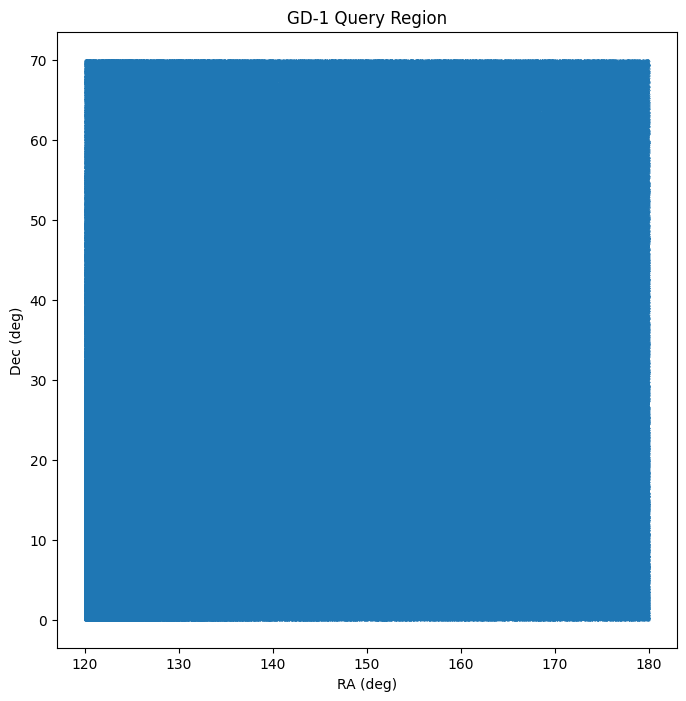

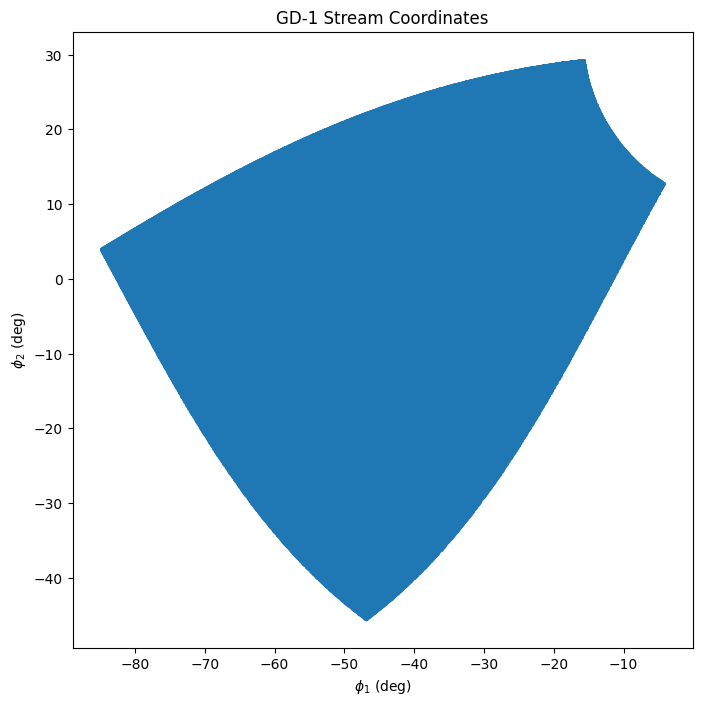

In [49]:
df = data.sample(n=3000000)






ra = np.radians(df["ra"].values)
dec = np.radians(df["dec"].values)

# Equatorial Cartesian coordinates

x = np.cos(dec) * np.cos(ra)
y = np.cos(dec) * np.sin(ra)
z = np.sin(dec)

vec = np.vstack([x, y, z])



R = np.array([
[-0.4776303088, -0.1738432154,  0.8611897727],
[ 0.5108445890, -0.8524449229,  0.1112450420],
[ 0.7147776536,  0.4930681392,  0.4959603976]
])

rot = R @ vec

x2 = rot[0]
y2 = rot[1]
z2 = rot[2]

phi1 = np.degrees(np.arctan2(y2, x2))
phi2 = np.degrees(np.arcsin(z2))

df["phi1"] = phi1
df["phi2"] = phi2





# PLOTTING RA DEC

plt.figure(figsize=(8,8))

plt.scatter(
    df["ra"],
    df["dec"],
    s=0.1
)

plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("GD-1 Query Region")

plt.show()







# PLOTTING STREAM COORDINATES


plt.figure(figsize=(8,8))

plt.scatter(
    df["phi1"],
    df["phi2"],
    s=0.1
)

plt.xlabel(r"$\phi_1$ (deg)")
plt.ylabel(r"$\phi_2$ (deg)")
plt.title("GD-1 Stream Coordinates")

plt.show()


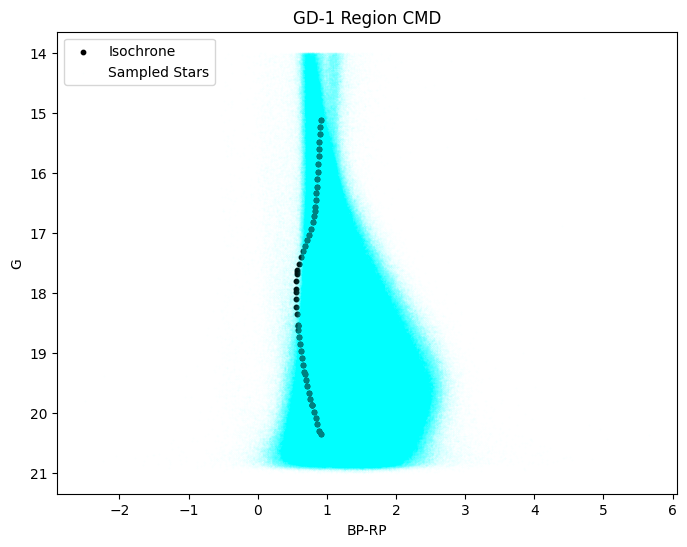

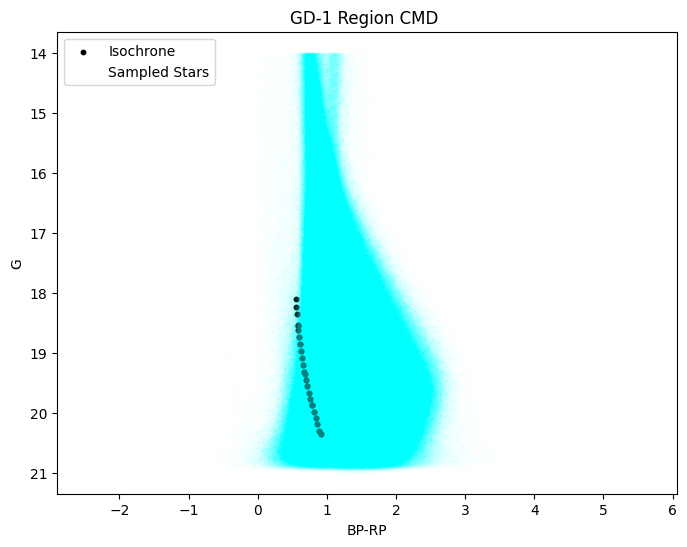

In [55]:
# HR DIAGRAM



isochrone = {           # Apparant G_mag
    "g": [
20.362, 20.298, 20.185, 20.086, 19.989,
19.874, 19.865, 19.776, 19.667, 19.561, 19.456, 19.360, 19.313,
19.199, 19.085, 18.965, 18.855, 18.739, 18.613, 18.557, 18.533,
18.359, 18.231, 18.102, 17.986, 17.938, 17.797, 17.684, 17.658,
17.627, 17.513, 17.408, 17.308, 17.214, 17.124, 17.035, 16.940,
16.827, 16.720, 16.641, 16.563, 16.456, 16.343, 16.230, 16.101,
15.986, 15.860, 15.725, 15.606, 15.482, 15.360, 15.240, 15.122
],

    "bp_rp": [
0.909, 0.893, 0.865, 0.838, 0.814,
0.785, 0.783, 0.763, 0.741, 0.720, 0.701, 0.683, 0.675,
0.658, 0.641, 0.625, 0.612, 0.600, 0.588, 0.583, 0.580,
0.567, 0.559, 0.553, 0.550, 0.551, 0.557, 0.566, 0.569,
0.574, 0.595, 0.620, 0.651, 0.685, 0.719, 0.749, 0.777,
0.801, 0.818, 0.828, 0.834, 0.843, 0.850, 0.856, 0.863,
0.868, 0.874, 0.880, 0.886, 0.892, 0.898, 0.903, 0.909
]
}

iso = pd.DataFrame(isochrone)



plt.figure(figsize=(8,6))

plt.scatter(
    iso["bp_rp"],
    iso["g"],
    s=10,
    c='black',
    label="Isochrone"
)

plt.scatter(
    df["bp_rp"],
    df["g"],
    s=0.1,
    c='cyan',
    alpha=0.02,
    label="Sampled Stars"
)

plt.gca().invert_yaxis()

plt.xlabel("BP-RP")
plt.ylabel("G")
plt.legend(loc="upper left")
plt.title("GD-1 Region CMD")

plt.show()




# Furthur restricting to near the GD-1 Stream (i.e with Apparent G_mag greater than 18)

iso=iso[iso["g"]>18]



plt.figure(figsize=(8,6))

plt.scatter(
    iso["bp_rp"],
    iso["g"],
    s=10,
    c='black',
    label="Isochrone"
)



plt.scatter(
    df["bp_rp"],
    df["g"],
    s=0.1,
    c='cyan',
    alpha=0.02,
    label="Sampled Stars"
)

plt.gca().invert_yaxis()

plt.xlabel("BP-RP")
plt.ylabel("G")
plt.legend(loc="upper left")
plt.title("GD-1 Region CMD ")

plt.show()



No. of Stars in the Selected Cluster : 1979413


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


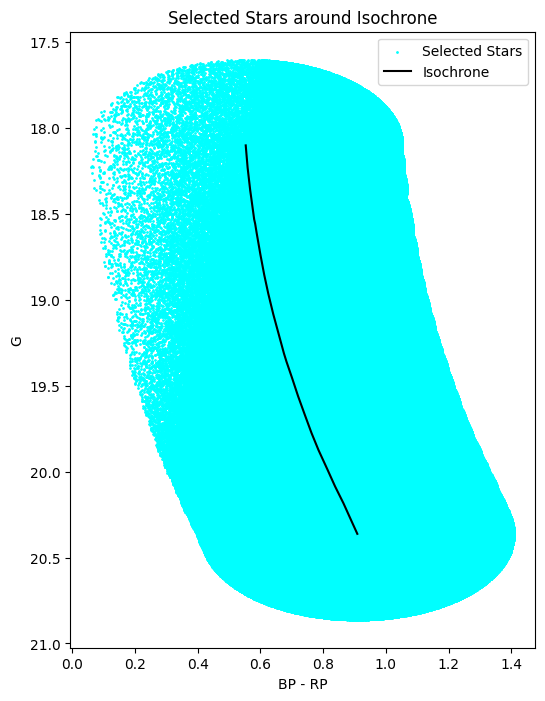

In [51]:
tree = cKDTree ( np.column_stack([iso["bp_rp"], iso["g"]]))


dist, _ = tree.query ( np.column_stack([data["bp_rp"], data["g"]]), k=1 )


cluster = data[dist < 0.5]

print ("\nNo. of Stars in the Selected Cluster :", len(cluster))



plt.figure(figsize=(6,8))

plt.scatter(
    cluster["bp_rp"],
    cluster["g"],
    s=1,
    color="cyan",
    label="Selected Stars"
)


plt.plot(
    iso["bp_rp"],
    iso["g"],
    color="black",
    label="Isochrone"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("Selected Stars around Isochrone")
plt.legend()

plt.show()

/tmp/ipykernel_14133/540520101.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster["phi1"] = gd1.phi1
/tmp/ipykernel_14133/540520101.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster["phi2"] = gd1.phi2
/tmp/ipykernel_14133/540520101.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

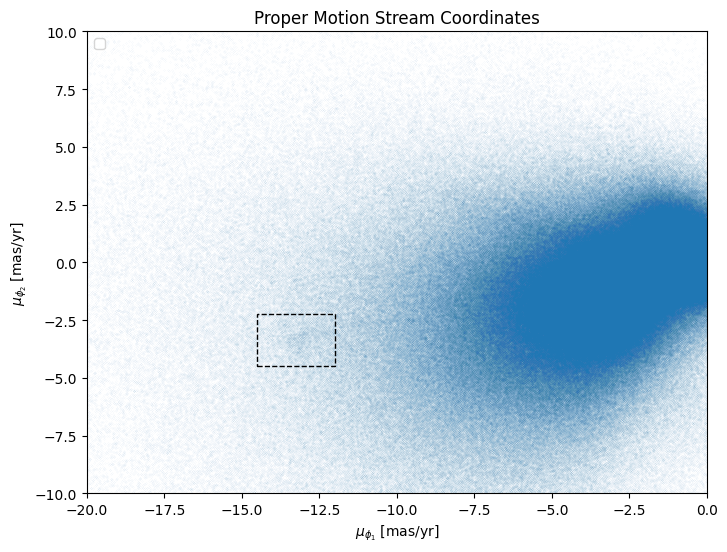

In [53]:
ra=cluster["ra"].values
dec=cluster["dec"].values
pmra=cluster["pmra"].values
pmdec=cluster["pmdec"].values


c = SkyCoord(
    ra=ra*u.deg,
    dec=dec*u.deg,
    pm_ra_cosdec=pmra*u.mas/u.yr,
    pm_dec=pmdec*u.mas/u.yr
)

gd1 = c.transform_to(GD1Koposov10())

cluster["phi1"] = gd1.phi1
cluster["phi2"] = gd1.phi2

cluster["pm_phi1"] = gd1.pm_phi1_cosphi2
cluster["pm_phi2"]  = gd1.pm_phi2





# Plotting Proper Motion Stream Coordinates


plt.figure(figsize=(8,6))

plt.scatter(
    cluster["pm_phi1"],
    cluster["pm_phi2"],
    s=0.0002
)


plt.gca().add_patch(Rectangle(
        (-14.5, -4.5),
        2.5,
        2.25,
        fill=False,
        edgecolor='black',
        linestyle='--',
    )
)


plt.xlabel(r'$\mu_{\phi_1}$ [mas/yr]')
plt.ylabel(r'$\mu_{\phi_2}$ [mas/yr]')

plt.xlim(-20,0)
plt.ylim(-10,10)

plt.title("Proper Motion Stream Coordinates")
plt.legend(loc="upper left")

plt.show()


No. of Stars in the GD1_canditate Cluster : 8283


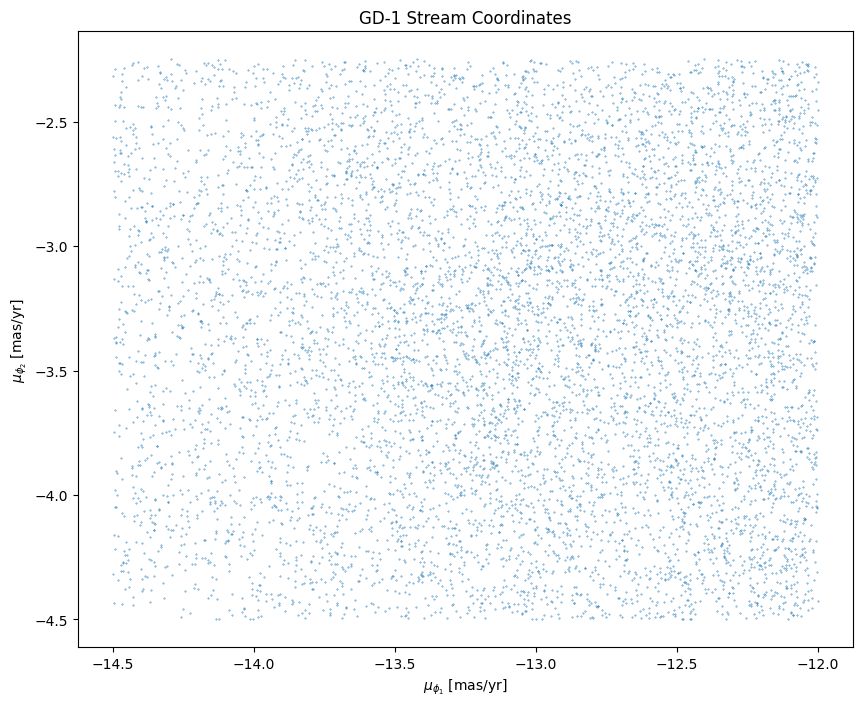

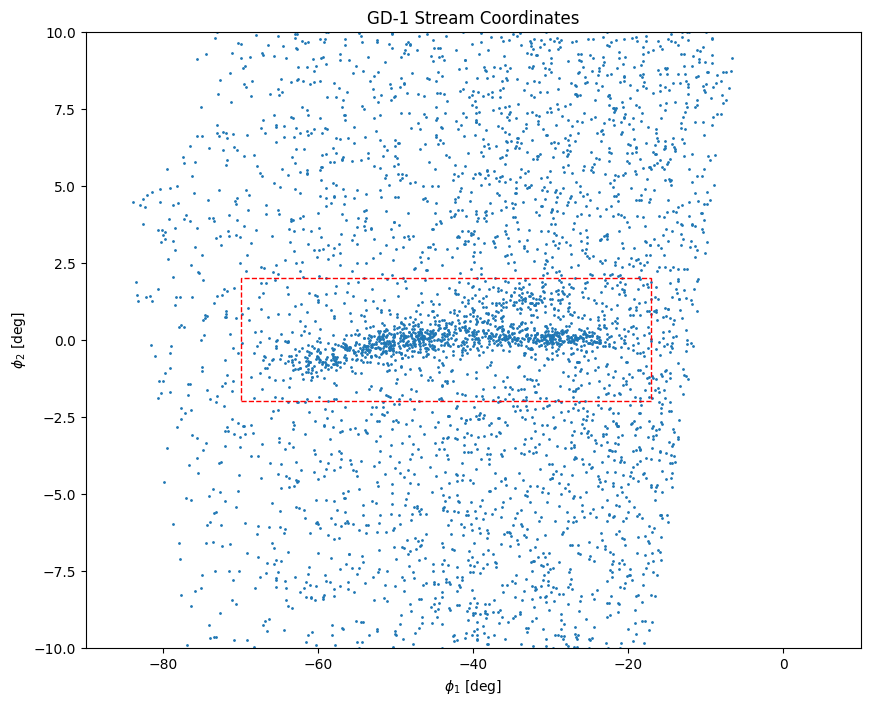

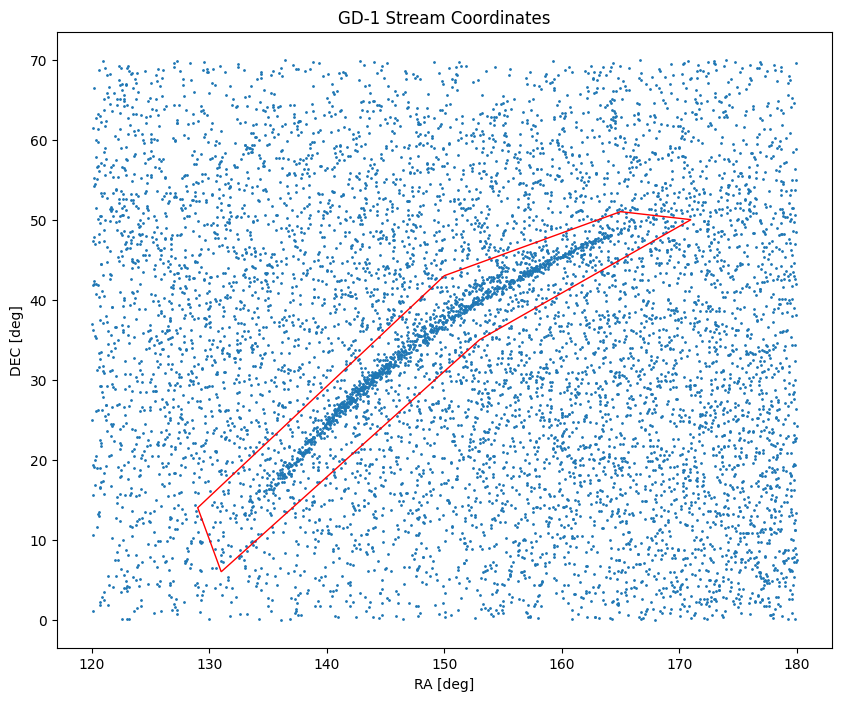

In [54]:
GD1_canditate = cluster[cluster["pm_phi1"].between(-14.5, -12.0) & cluster["pm_phi2"].between(-4.5, -2.25)]

print ("\nNo. of Stars in the GD1_canditate Cluster :", len(GD1_canditate))



plt.figure(figsize=(10,8))

plt.scatter(
    GD1_canditate["pm_phi1"],
    GD1_canditate["pm_phi2"],
    s=0.1
)



plt.xlabel(r'$\mu_{\phi_1}$ [mas/yr]')
plt.ylabel(r'$\mu_{\phi_2}$ [mas/yr]')


plt.title("GD-1 Stream Coordinates")

plt.show()


plt.figure(figsize=(10,8))

plt.scatter(
    GD1_canditate["phi1"],
    GD1_canditate["phi2"],
    s=1
)

plt.gca().add_patch(Rectangle(
        (-70, -2),
        53,
        4,
        fill=False,
        edgecolor='red',
        linestyle='--'
    )
)

plt.xlabel(r'$\phi_1$ [deg]')
plt.ylabel(r'$\phi_2$ [deg]')

plt.xlim(-90,10)
plt.ylim(-10,10)

plt.title("GD-1 Stream Coordinates")

plt.show()



plt.figure(figsize=(10,8))

plt.scatter(
     GD1_canditate["ra"],
     GD1_canditate["dec"],
     s=1
)

vertices = [[131,6],
            [129,14],
            [150,43],
            [165,51],
            [171,50],
            [153,35]]

plt.gca().add_patch(Polygon(
        vertices,
        fill=False,
        edgecolor='red'
    )
)


plt.xlabel(r'RA [deg]')
plt.ylabel(r'DEC [deg]')


plt.title("GD-1 Stream Coordinates")
plt.show()